# NHAMCS 2018-2022 Hierarchical Cascade Triage: Layer 1 LightGBM (SMOTE) + Layer 2 LightGBM (SMOTE) (`models/train_disaster_nhamcs_rf.ipynb`)

Implements a **Dual-Layer LightGBM Disaster Triage Cascade Pipeline** on the **CDC NHAMCS 2018-2022 Consolidated Dataset** (`datasets/nhamcs_2018_2022.csv`) with `StandardScaler` normalization and **SMOTE applied independently to both Layer 1 and Layer 2**.

### 🏗️ Hierarchical Dual-LightGBM Cascade Architecture
```mermaid
flowchart TD
    PATIENT["Patient Vital Signs (7 Scaled Vitals)"] --> L1["Layer 1: Binary LightGBM with SMOTE<br>(Trained on balanced data: Green vs Non-Green)"]
    L1 -- "Predicts Green (ESI 4-5)" --> GREEN["🟢 GREEN: Semi-urgent / Nonurgent"]
    L1 -- "Predicts Non-Green (ESI 1-3)" --> L2["Layer 2: Specialized LightGBM with SMOTE<br>(ESI 4-5 Excluded: Red vs Yellow Acuity)"]
    L2 -- "Predicts Red (ESI 1)" --> RED["🔴 RED: Immediate Resuscitation"]
    L2 -- "Predicts Yellow (ESI 2-3)" --> YELLOW["🟡 YELLOW: Emergent / Urgent"]
```

### 📋 Acuity Classes & Pipeline Layer Details
- **`RED (Class 0: ESI 1)`**: Immediate / Resuscitation
- **`YELLOW (Class 1: ESI 2-3)`**: Emergent + Urgent
- **`GREEN (Class 2: ESI 4-5)`**: Semi-urgent + Nonurgent
- **Layer 1 (LightGBM with SMOTE)**: Trained on all training visits with `SMOTE` balancing `GREEN (ESI 4-5)` ($13,379 \rightarrow 27,307$) to equal `NON-GREEN (ESI 1-3)` ($27,307$).
- **Layer 2 (LightGBM with SMOTE)**: Trained strictly on non-green visits (`mask: y_train != 2` with `ESI 4-5` removed), with `SMOTE` generating synthetic samples to balance `ESI 1` ($592 \rightarrow 26,715$) to match `ESI 2-3` ($26,715$).

In [1]:
# ---------------------------------------------------------------------------
# Step 1: Load NHAMCS Dataset, Map 3 Classes, Clean Codes & Apply StandardScaler
# ---------------------------------------------------------------------------
import os, json, pickle, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = '..' if os.path.basename(os.getcwd()) == 'models' else '.'
data_path = f'{ROOT}/datasets/nhamcs_2018_2022.csv'
if not os.path.exists(data_path) and os.path.exists('datasets/nhamcs_2018_2022.csv'):
    data_path = 'datasets/nhamcs_2018_2022.csv'
elif not os.path.exists(data_path) and os.path.exists('nhamcs_2018_2022.csv'):
    data_path = 'nhamcs_2018_2022.csv'
elif not os.path.exists(data_path) and os.path.exists(f'{ROOT}/datasets/ed2022.csv'):
    data_path = f'{ROOT}/datasets/ed2022.csv'

print(f"Loading NHAMCS Dataset from: {data_path} ...")
raw_df = pd.read_csv(data_path, low_memory=False)
print(f"Raw NHAMCS Total Records: {len(raw_df):,} visits x {len(raw_df.columns)} variables")

# Filter ONLY rows where IMMEDR is in 1..5 (Ignore -9, -8, 0, 7)
valid_mask = raw_df['IMMEDR'].isin([1, 2, 3, 4, 5])
df_filtered = raw_df[valid_mask].copy()
print(f"Filtered Cohort (IMMEDR in 1..5): {len(df_filtered):,} visits ({len(df_filtered)/len(raw_df)*100:.2f}% of total)")

# Extract Features
feature_cols = ['AGE', 'SEX', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT']
X_raw = df_filtered[feature_cols].copy()

# Clean special missing / unmeasured codes to np.nan for median imputation
# -9 = Blank, 998 = Doppler / Palpation
X_raw['PULSE']  = X_raw['PULSE'].replace([-9, 998], np.nan)
X_raw['RESPR']  = X_raw['RESPR'].replace([-9], np.nan)
X_raw['BPSYS']  = X_raw['BPSYS'].replace([-9], np.nan)
X_raw['BPDIAS'] = X_raw['BPDIAS'].replace([-9, 998], np.nan)
X_raw['POPCT']  = X_raw['POPCT'].replace([-9], np.nan)

# Recode SEX: 1=Female -> 0, 2=Male -> 1
X_raw['SEX'] = (X_raw['SEX'] == 2).astype(float)

# Target 3-Class Mapping: RED=0 (ESI 1), YELLOW=1 (ESI 2-3), GREEN=2 (ESI 4-5)
immedr_vals = df_filtered['IMMEDR'].values
y_all = np.where(immedr_vals == 1, 0, np.where(immedr_vals <= 3, 1, 2))
LABELS = ['RED', 'YELLOW', 'GREEN']
CLASS_DESCRIPTIONS = ['RED (ESI 1: Immediate)', 'YELLOW (ESI 2-3: Emergent/Urgent)', 'GREEN (ESI 4-5: Semi/Nonurgent)']

print("\n3-Class Disaster Triage Cohort Distribution:")
for c_idx, name in enumerate(CLASS_DESCRIPTIONS):
    count = np.sum(y_all == c_idx)
    print(f"  * Class {c_idx} ({name:36s}): {count:6d} ({count/len(y_all)*100:5.2f}%)")

# Stratified 3-way split: 70% Train, 15% Validation, 15% Holdout Test
itr, itmp = train_test_split(np.arange(len(y_all)), test_size=0.30, stratify=y_all, random_state=42)
iva, ite = train_test_split(itmp, test_size=0.50, stratify=y_all[itmp], random_state=42)

X_tr_raw  = X_raw.iloc[itr].values
X_val_raw = X_raw.iloc[iva].values
X_te_raw  = X_raw.iloc[ite].values

y_train = y_all[itr]
y_val   = y_all[iva]
y_test  = y_all[ite]

# Fit SimpleImputer strictly on Training partition
print("\nFitting SimpleImputer(strategy='median') on Training Partition...")
imputer = SimpleImputer(strategy='median')
raw_tr_imp  = imputer.fit_transform(X_tr_raw)
raw_val_imp = imputer.transform(X_val_raw)
raw_te_imp  = imputer.transform(X_te_raw)

# Fit StandardScaler strictly on Training partition
print("Fitting StandardScaler() on Imputed Training Partition...")
scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(raw_tr_imp)
X_val_scaled = scaler.transform(raw_val_imp)
X_te_scaled  = scaler.transform(raw_te_imp)

print(f"Scaled Data Partitions: Train={X_tr_scaled.shape}, Val={X_val_scaled.shape}, Test={X_te_scaled.shape}")

Loading NHAMCS Dataset from: ../datasets/nhamcs_2018_2022.csv ...


Raw NHAMCS Total Records: 86,864 visits x 954 variables


Filtered Cohort (IMMEDR in 1..5): 58,124 visits (66.91% of total)

3-Class Disaster Triage Cohort Distribution:
  * Class 0 (RED (ESI 1: Immediate)              ):    846 ( 1.46%)
  * Class 1 (YELLOW (ESI 2-3: Emergent/Urgent)   ):  38165 (65.66%)
  * Class 2 (GREEN (ESI 4-5: Semi/Nonurgent)     ):  19113 (32.88%)

Fitting SimpleImputer(strategy='median') on Training Partition...
Fitting StandardScaler() on Imputed Training Partition...
Scaled Data Partitions: Train=(40686, 7), Val=(8719, 7), Test=(8719, 7)


In [2]:
# ---------------------------------------------------------------------------
# Step 2: Train Layer 1 LightGBM (with SMOTE) & Layer 2 LightGBM (with SMOTE)
# ---------------------------------------------------------------------------
print("1. Applying SMOTE to Layer 1 (Green vs Non-Green)...")
y_tr_l1 = (y_train == 2).astype(int) # 1 = GREEN (ESI 4-5), 0 = NON-GREEN (ESI 1-3)
print("  * Layer 1 Before SMOTE:", {'NON-GREEN (ESI 1-3)': np.sum(y_tr_l1 == 0), 'GREEN (ESI 4-5)': np.sum(y_tr_l1 == 1)})

smote_l1 = SMOTE(random_state=42)
X_tr_l1_smote, y_tr_l1_smote = smote_l1.fit_resample(X_tr_scaled, y_tr_l1)
print("  * Layer 1 After SMOTE :", {'NON-GREEN (ESI 1-3)': np.sum(y_tr_l1_smote == 0), 'GREEN (ESI 4-5)': np.sum(y_tr_l1_smote == 1)})
print(f"  * Layer 1 Expanded Training Size: {X_tr_l1_smote.shape[0]:,} samples")

print("\nTraining Layer 1 LightGBM on SMOTE-Resampled Green vs Non-Green Data...")
l1_lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
l1_lgbm.fit(X_tr_l1_smote, y_tr_l1_smote)
print("✓ Layer 1 LightGBM ready!")

print("\n2. Filtering ESI 4-5 and Applying SMOTE to Layer 2 (RED vs YELLOW)...")
mask_l2 = (y_train != 2) # Strictly exclude ESI 4-5 (GREEN)
X_tr_l2 = X_tr_scaled[mask_l2]
y_tr_l2 = y_train[mask_l2] # 0 = RED (ESI 1), 1 = YELLOW (ESI 2-3)

print("  * Layer 2 Before SMOTE:", {'RED (ESI 1)': np.sum(y_tr_l2 == 0), 'YELLOW (ESI 2-3)': np.sum(y_tr_l2 == 1)})
smote_l2 = SMOTE(random_state=42)
X_tr_l2_smote, y_tr_l2_smote = smote_l2.fit_resample(X_tr_l2, y_tr_l2)
print("  * Layer 2 After SMOTE :", {'RED (ESI 1)': np.sum(y_tr_l2_smote == 0), 'YELLOW (ESI 2-3)': np.sum(y_tr_l2_smote == 1)})
print(f"  * Layer 2 Expanded Training Size: {X_tr_l2_smote.shape[0]:,} samples")

print("\nTraining Layer 2 LightGBM on SMOTE-Resampled Non-Green Data...")
l2_lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
l2_lgbm.fit(X_tr_l2_smote, y_tr_l2_smote)
print(f"✓ Layer 2 LightGBM binary classifier ready!")

# Train Baseline Standalone RF with SMOTE for side-by-side benchmarking
print("\n3. Training Baseline Standalone Random Forest with SMOTE...")
smote_base = SMOTE(random_state=42)
X_tr_smote_all, y_tr_smote_all = smote_base.fit_resample(X_tr_scaled, y_train)
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_tr_smote_all, y_tr_smote_all)
print("✓ Baseline Standalone Random Forest ready!")

1. Applying SMOTE to Layer 1 (Green vs Non-Green)...
  * Layer 1 Before SMOTE: {'NON-GREEN (ESI 1-3)': np.int64(27307), 'GREEN (ESI 4-5)': np.int64(13379)}


  * Layer 1 After SMOTE : {'NON-GREEN (ESI 1-3)': np.int64(27307), 'GREEN (ESI 4-5)': np.int64(27307)}
  * Layer 1 Expanded Training Size: 54,614 samples

Training Layer 1 LightGBM on SMOTE-Resampled Green vs Non-Green Data...


✓ Layer 1 LightGBM ready!

2. Filtering ESI 4-5 and Applying SMOTE to Layer 2 (RED vs YELLOW)...
  * Layer 2 Before SMOTE: {'RED (ESI 1)': np.int64(592), 'YELLOW (ESI 2-3)': np.int64(26715)}
  * Layer 2 After SMOTE : {'RED (ESI 1)': np.int64(26715), 'YELLOW (ESI 2-3)': np.int64(26715)}
  * Layer 2 Expanded Training Size: 53,430 samples

Training Layer 2 LightGBM on SMOTE-Resampled Non-Green Data...


✓ Layer 2 LightGBM binary classifier ready!

3. Training Baseline Standalone Random Forest with SMOTE...


✓ Baseline Standalone Random Forest ready!


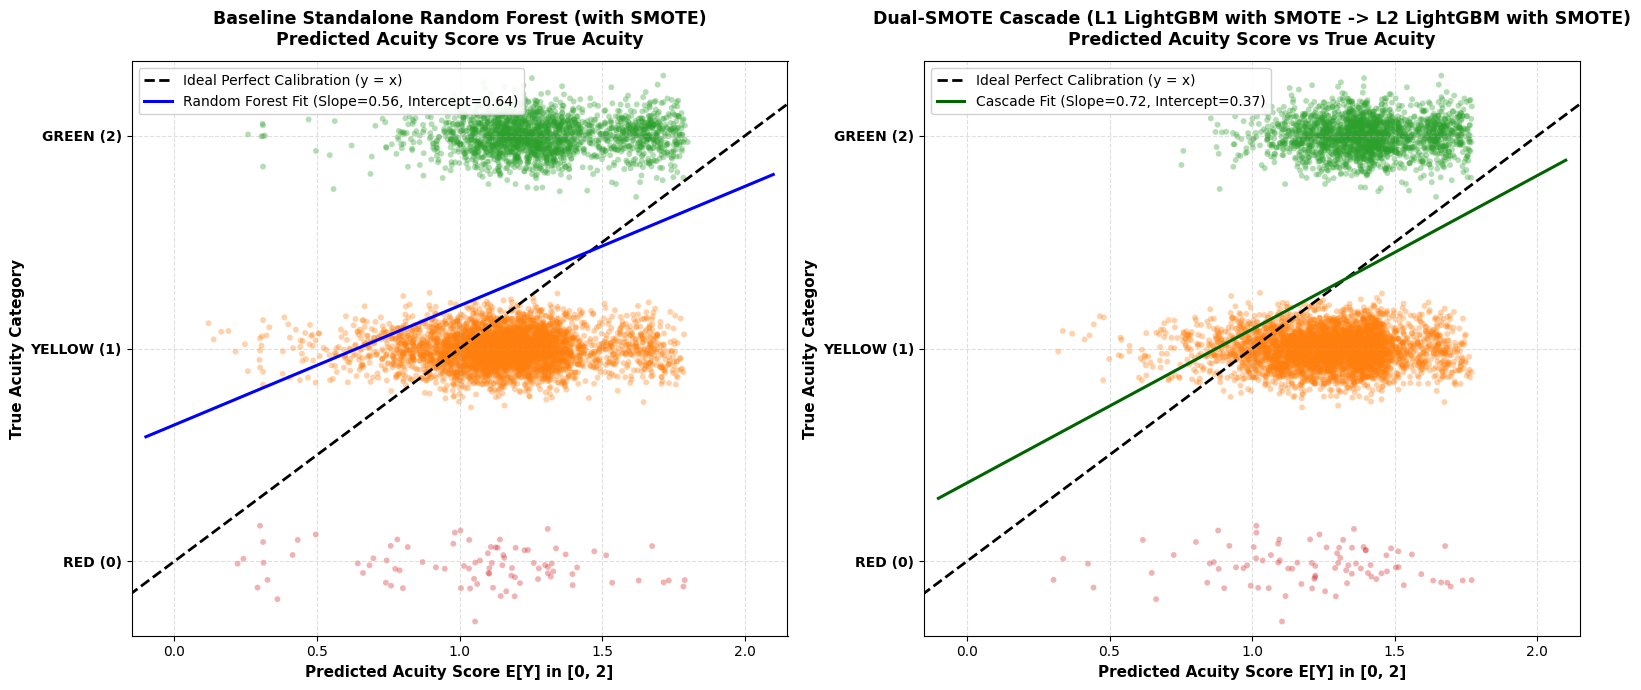

Side-by-Side Calibration Scatterplots saved to: ../plots/validation_scatter_nhamcs_rf_vs_cascade.png


In [3]:
# ---------------------------------------------------------------------------
# Step 2.5: Predicted Acuity Score Scatterplots (Baseline RF vs Cascade Pipeline)
# ---------------------------------------------------------------------------
plots_dir = f'{ROOT}/plots'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'image'), exist_ok=True)

# Compute Cascade Probabilities on Validation Partition
p_val_l1       = l1_lgbm.predict_proba(X_val_scaled)
p_val_green    = p_val_l1[:, 1]
p_val_nongreen = p_val_l1[:, 0]
p_val_l2       = l2_lgbm.predict_proba(X_val_scaled)
p_val_red      = p_val_nongreen * p_val_l2[:, 0]
p_val_yellow   = p_val_nongreen * p_val_l2[:, 1]
val_probs_cascade = np.column_stack([p_val_red, p_val_yellow, p_val_green])

weights = np.array([0.0, 1.0, 2.0])
val_score_rf_base = np.dot(rf_baseline.predict_proba(X_val_scaled), weights)
val_score_cascade = np.dot(val_probs_cascade, weights)

np.random.seed(42)
N_PLOT = min(6000, len(y_val))
sample_idx = np.random.choice(len(y_val), N_PLOT, replace=False)

y_val_samp = y_val[sample_idx]
jitter_y = y_val_samp + np.random.normal(0, 0.08, size=N_PLOT)
rf_samp      = val_score_rf_base[sample_idx]
cascade_samp = val_score_cascade[sample_idx]

cat_colors = np.array(['#d62728', '#ff7f0e', '#2ca02c'])
point_colors = cat_colors[y_val_samp]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
x_vals = np.linspace(-0.1, 2.1, 100)

# Panel 1: Baseline RF with SMOTE
ax1 = axes[0]
ax1.scatter(rf_samp, jitter_y, c=point_colors, alpha=0.35, s=18, edgecolors='none')
ax1.plot([-0.2, 2.2], [-0.2, 2.2], 'k--', linewidth=2.0, label='Ideal Perfect Calibration (y = x)')
m_rf, b_rf = np.polyfit(rf_samp, y_val_samp, 1)
ax1.plot(x_vals, m_rf * x_vals + b_rf, color='blue', linewidth=2.2,
         label=f'Random Forest Fit (Slope={m_rf:.2f}, Intercept={b_rf:.2f})')
ax1.set_title('Baseline Standalone Random Forest (with SMOTE)\nPredicted Acuity Score vs True Acuity', fontsize=12.5, fontweight='bold', pad=12)
ax1.set_xlabel('Predicted Acuity Score E[Y] in [0, 2]', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Acuity Category', fontsize=11, fontweight='bold')
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(['RED (0)', 'YELLOW (1)', 'GREEN (2)'], fontweight='bold')
ax1.set_xlim([-0.15, 2.15])
ax1.set_ylim([-0.35, 2.35])
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=10, frameon=True, framealpha=0.9)

# Panel 2: Dual-SMOTE Dual-LightGBM Cascade
ax2 = axes[1]
ax2.scatter(cascade_samp, jitter_y, c=point_colors, alpha=0.35, s=18, edgecolors='none')
ax2.plot([-0.2, 2.2], [-0.2, 2.2], 'k--', linewidth=2.0, label='Ideal Perfect Calibration (y = x)')
m_casc, b_casc = np.polyfit(cascade_samp, y_val_samp, 1)
ax2.plot(x_vals, m_casc * x_vals + b_casc, color='darkgreen', linewidth=2.2,
         label=f'Cascade Fit (Slope={m_casc:.2f}, Intercept={b_casc:.2f})')
ax2.set_title('Dual-SMOTE Cascade (L1 LightGBM with SMOTE -> L2 LightGBM with SMOTE)\nPredicted Acuity Score vs True Acuity', fontsize=12.5, fontweight='bold', pad=12)
ax2.set_xlabel('Predicted Acuity Score E[Y] in [0, 2]', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Acuity Category', fontsize=11, fontweight='bold')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['RED (0)', 'YELLOW (1)', 'GREEN (2)'], fontweight='bold')
ax2.set_xlim([-0.15, 2.15])
ax2.set_ylim([-0.35, 2.35])
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, frameon=True, framealpha=0.9)

plt.tight_layout()
scatter_out = os.path.join(plots_dir, 'validation_scatter_nhamcs_rf_vs_cascade.png')
plt.savefig(scatter_out, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'validation_scatter_nhamcs_rf_vs_cascade.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Side-by-Side Calibration Scatterplots saved to: {scatter_out}")

In [4]:
# ---------------------------------------------------------------------------
# Step 3: Holdout Test Set Evaluation (Baseline RF vs Dual-SMOTE Dual-LGBM Cascade)
# ---------------------------------------------------------------------------
# 1. Baseline Predictions
test_probs_rf_base = rf_baseline.predict_proba(X_te_scaled)
test_preds_rf_base = rf_baseline.predict(X_te_scaled)

# 2. Cascaded Predictions
p_te_l1          = l1_lgbm.predict_proba(X_te_scaled)
p_te_green       = p_te_l1[:, 1]
p_te_nongreen    = p_te_l1[:, 0]
pred_l1_is_green = (l1_lgbm.predict(X_te_scaled) == 1)

p_te_l2            = l2_lgbm.predict_proba(X_te_scaled)
pred_l2_red_or_yel = l2_lgbm.predict(X_te_scaled) # 0=RED, 1=YELLOW

p_te_red           = p_te_nongreen * p_te_l2[:, 0]
p_te_yellow        = p_te_nongreen * p_te_l2[:, 1]
test_probs_cascade = np.column_stack([p_te_red, p_te_yellow, p_te_green])
test_preds_cascade = np.where(pred_l1_is_green, 2, pred_l2_red_or_yel)

def evaluate_3class_detailed(y_true, y_pred, probs, model_name):
    rec0 = recall_score(y_true == 0, y_pred == 0)
    rec1 = recall_score(y_true == 1, y_pred == 1)
    rec2 = recall_score(y_true == 2, y_pred == 2)
    
    spec0 = recall_score(y_true != 0, y_pred != 0)
    spec1 = recall_score(y_true != 1, y_pred != 1)
    spec2 = recall_score(y_true != 2, y_pred != 2)
    
    auc0 = roc_auc_score(y_true == 0, probs[:, 0])
    auc1 = roc_auc_score(y_true == 1, probs[:, 1])
    auc2 = roc_auc_score(y_true == 2, probs[:, 2])
    
    return {
        'Model': model_name,
        'Overall_Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Balanced_Accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'RED_Sensitivity (ESI 1)': round(rec0, 4),
        'YELLOW_Sensitivity (ESI 2-3)': round(rec1, 4),
        'GREEN_Sensitivity (ESI 4-5)': round(rec2, 4),
        'RED_Specificity': round(spec0, 4),
        'YELLOW_Specificity': round(spec1, 4),
        'GREEN_Specificity': round(spec2, 4),
        'Macro_ROC_AUC': round(roc_auc_score(y_true, probs, multi_class='ovr', average='macro'), 4),
        'RED_ROC_AUC': round(auc0, 4),
        'YELLOW_ROC_AUC': round(auc1, 4),
        'GREEN_ROC_AUC': round(auc2, 4)
    }

res_rf_base = evaluate_3class_detailed(y_test, test_preds_rf_base, test_probs_rf_base, 'Baseline RF (with SMOTE)')
res_cascade = evaluate_3class_detailed(y_test, test_preds_cascade, test_probs_cascade, 'Dual-SMOTE Cascade (L1 LightGBM -> L2 LightGBM)')

comparison_df = pd.DataFrame([res_rf_base, res_cascade])

print("========================================================================================")
print("   NHAMCS 2018-2022 HOLDOUT EVALUATION: BASELINE RF VS DUAL-SMOTE CASCADE PIPELINE")
print("========================================================================================")
print(comparison_df.to_string(index=False))
print("========================================================================================\n")

reports_dir = f'{ROOT}/reports'
os.makedirs(reports_dir, exist_ok=True)
report_path = os.path.join(reports_dir, 'nhamcs_2018_2022_cascade_rf_report.csv')
comparison_df.to_csv(report_path, index=False)
print(f"Metrics report saved to: {report_path}")

   NHAMCS 2018-2022 HOLDOUT EVALUATION: BASELINE RF VS DUAL-SMOTE CASCADE PIPELINE
                                          Model  Overall_Accuracy  Balanced_Accuracy  RED_Sensitivity (ESI 1)  YELLOW_Sensitivity (ESI 2-3)  GREEN_Sensitivity (ESI 4-5)  RED_Specificity  YELLOW_Specificity  GREEN_Specificity  Macro_ROC_AUC  RED_ROC_AUC  YELLOW_ROC_AUC  GREEN_ROC_AUC
                       Baseline RF (with SMOTE)            0.6306             0.4364                   0.1181                        0.7235                       0.4677           0.9596              0.4830             0.7734         0.6469       0.6219          0.6402         0.6785
Dual-SMOTE Cascade (L1 LightGBM -> L2 LightGBM)            0.6573             0.4383                   0.1024                        0.7845                       0.4280           0.9821              0.4302             0.8072         0.6520       0.6166          0.6526         0.6867

Metrics report saved to: ../reports/nhamcs_2018_2022_cascade_rf_

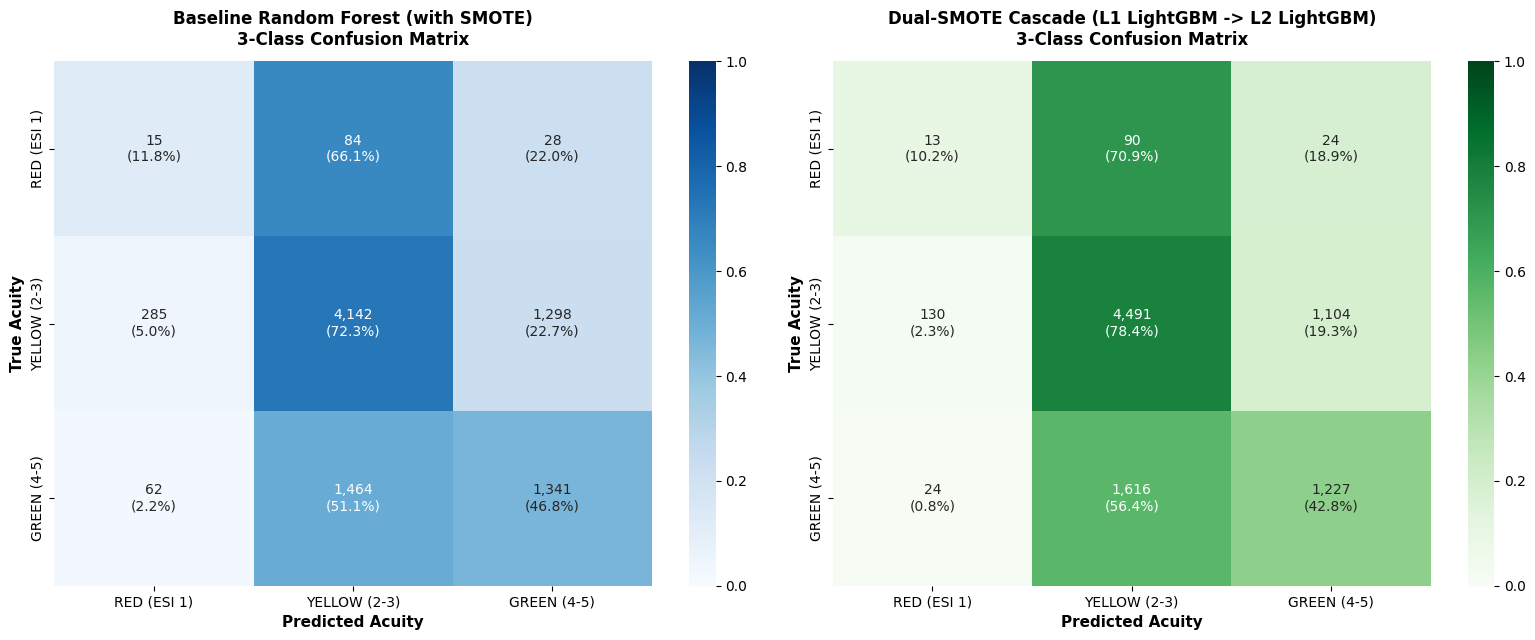

Confusion Matrix plot saved to: ../plots/nhamcs_rf_confusion_matrix.png


In [5]:
# ---------------------------------------------------------------------------
# Step 4: Side-by-Side 3x3 Confusion Matrices (Baseline RF vs Dual-SMOTE Cascade Pipeline)
# ---------------------------------------------------------------------------
cm_base    = confusion_matrix(y_test, test_preds_rf_base, labels=[0, 1, 2])
cm_cascade = confusion_matrix(y_test, test_preds_cascade, labels=[0, 1, 2])

cm_base_norm    = cm_base.astype('float') / cm_base.sum(axis=1)[:, np.newaxis]
cm_cascade_norm = cm_cascade.astype('float') / cm_cascade.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Panel 1: Baseline RF Heatmap
annot_base = np.empty_like(cm_base, dtype=object)
for i in range(3):
    for j in range(3):
        annot_base[i, j] = f"{cm_base[i, j]:,}\n({cm_base_norm[i, j]*100:.1f}%)"
sns.heatmap(cm_base_norm, annot=annot_base, fmt='', cmap='Blues', cbar=True, ax=axes[0], vmin=0, vmax=1,
            xticklabels=['RED (ESI 1)', 'YELLOW (2-3)', 'GREEN (4-5)'],
            yticklabels=['RED (ESI 1)', 'YELLOW (2-3)', 'GREEN (4-5)'])
axes[0].set_title('Baseline Random Forest (with SMOTE)\n3-Class Confusion Matrix', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Acuity', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Acuity', fontsize=11, fontweight='bold')

# Panel 2: Dual-SMOTE Cascade Pipeline Heatmap
annot_casc = np.empty_like(cm_cascade, dtype=object)
for i in range(3):
    for j in range(3):
        annot_casc[i, j] = f"{cm_cascade[i, j]:,}\n({cm_cascade_norm[i, j]*100:.1f}%)"
sns.heatmap(cm_cascade_norm, annot=annot_casc, fmt='', cmap='Greens', cbar=True, ax=axes[1], vmin=0, vmax=1,
            xticklabels=['RED (ESI 1)', 'YELLOW (2-3)', 'GREEN (4-5)'],
            yticklabels=['RED (ESI 1)', 'YELLOW (2-3)', 'GREEN (4-5)'])
axes[1].set_title('Dual-SMOTE Cascade (L1 LightGBM -> L2 LightGBM)\n3-Class Confusion Matrix', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Acuity', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Acuity', fontsize=11, fontweight='bold')

plt.tight_layout()
cm_out_path = os.path.join(plots_dir, 'nhamcs_rf_confusion_matrix.png')
plt.savefig(cm_out_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix plot saved to: {cm_out_path}")

In [6]:
# ---------------------------------------------------------------------------
# Step 5: Feature Density & Distribution Plots across Disaster Acuity Classes
# ---------------------------------------------------------------------------
density_dir = os.path.join(plots_dir, 'density_nhamcs_rf')
os.makedirs(density_dir, exist_ok=True)

df_train_plot = pd.DataFrame(raw_tr_imp, columns=feature_cols)
df_train_plot['Acuity_Level'] = [LABELS[k] for k in y_train]

disaster_palette = {
    'RED': '#d62728',    # Red (ESI 1: Immediate)
    'YELLOW': '#ff7f0e', # Orange (ESI 2-3: Emergent/Urgent)
    'GREEN': '#2ca02c'   # Green (ESI 4-5: Semi/Nonurgent)
}

print(f"Generating density & distribution plots for {len(feature_cols)} clinical features...")
for feat in feature_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    if feat == 'SEX':
        prop_df = df_train_plot.groupby('Acuity_Level')[feat].mean().reset_index(name='Proportion')
        sns.barplot(data=prop_df, x='Acuity_Level', y='Proportion', palette=disaster_palette, ax=ax, edgecolor='black',
                    order=LABELS)
        ax.set_title(f"{feat} (Male Proportion by Disaster Acuity Level)", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel("Acuity Level", fontsize=11, fontweight='bold')
        ax.set_ylabel("Male Proportion", fontsize=11, fontweight='bold')
        for p in ax.patches:
            ax.annotate(f"{p.get_height()*100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2),
                        textcoords='offset points')
    else:
        sns.kdeplot(
            data=df_train_plot,
            x=feat,
            hue='Acuity_Level',
            hue_order=LABELS,
            palette=disaster_palette,
            common_norm=False,
            fill=True,
            alpha=0.20,
            linewidth=2.0,
            ax=ax
        )
        ax.set_title(f"NHAMCS Feature Density: {feat} across Acuity Classes", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel(feat, fontsize=11, fontweight='bold')
        ax.set_ylabel("Density", fontsize=11, fontweight='bold')
        
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(density_dir, f"density_nhamcs_{feat}.png"), dpi=300, bbox_inches='tight')
    plt.close()

print(f"✓ All {len(feature_cols)} feature density plots saved in: {density_dir}")

Generating density & distribution plots for 7 clinical features...


✓ All 7 feature density plots saved in: ../plots/density_nhamcs_rf


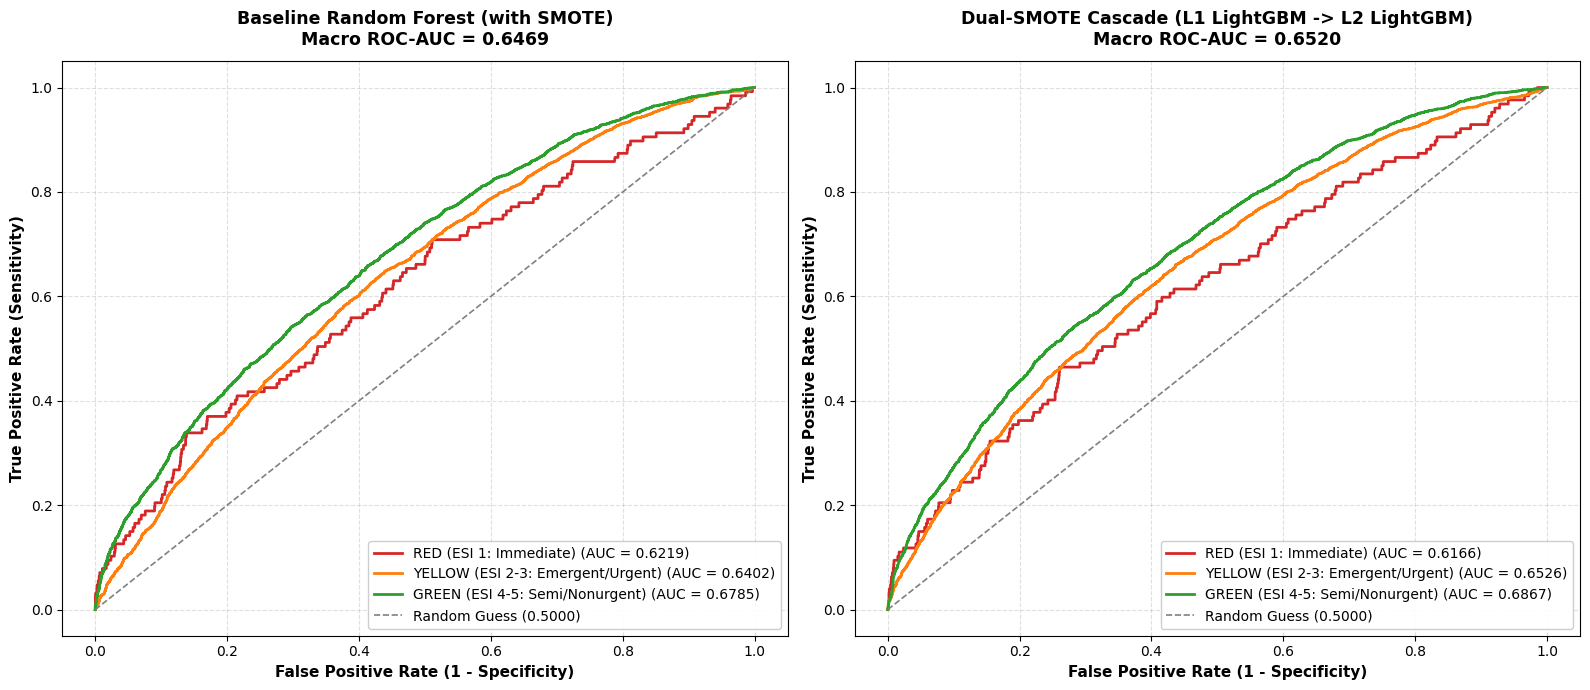

Comparative ROC-AUC curves saved to: ../plots/nhamcs_rf_roc_auc.png


In [7]:
# ---------------------------------------------------------------------------
# Step 6: Comparative 3-Class Multiclass ROC-AUC Curves
# ---------------------------------------------------------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes  = 3

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: Baseline RF
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_probs_rf_base[:, i])
    auc_i = auc(fpr_i, tpr_i)
    axes[0].plot(fpr_i, tpr_i, color=disaster_palette[LABELS[i]], linewidth=2.0,
                 label=f"{CLASS_DESCRIPTIONS[i]} (AUC = {auc_i:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', color='gray', linewidth=1.2, label='Random Guess (0.5000)')
axes[0].set_title(f"Baseline Random Forest (with SMOTE)\nMacro ROC-AUC = {res_rf_base['Macro_ROC_AUC']:.4f}", fontsize=12.5, fontweight='bold', pad=12)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10, frameon=True, framealpha=0.95)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Panel 2: Dual-SMOTE Dual-LightGBM Cascade Pipeline
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_probs_cascade[:, i])
    auc_i = auc(fpr_i, tpr_i)
    axes[1].plot(fpr_i, tpr_i, color=disaster_palette[LABELS[i]], linewidth=2.0,
                 label=f"{CLASS_DESCRIPTIONS[i]} (AUC = {auc_i:.4f})")
axes[1].plot([0, 1], [0, 1], 'k--', color='gray', linewidth=1.2, label='Random Guess (0.5000)')
axes[1].set_title(f"Dual-SMOTE Cascade (L1 LightGBM -> L2 LightGBM)\nMacro ROC-AUC = {res_cascade['Macro_ROC_AUC']:.4f}", fontsize=12.5, fontweight='bold', pad=12)
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10, frameon=True, framealpha=0.95)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
roc_out_path = os.path.join(plots_dir, 'nhamcs_rf_roc_auc.png')
plt.savefig(roc_out_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_rf_roc_auc.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Comparative ROC-AUC curves saved to: {roc_out_path}")

In [8]:
# ---------------------------------------------------------------------------
# Step 7: Export Production Bundle & Deployment Manifest (Dual-SMOTE Pipeline)
# ---------------------------------------------------------------------------
deploy_dir = f'{ROOT}/deploy'
os.makedirs(deploy_dir, exist_ok=True)

bundle_data = {
    'l1_lgbm': l1_lgbm,
    'l2_lgbm': l2_lgbm,
    'rf_baseline': rf_baseline,
    'scaler': scaler,
    'imputer': imputer,
    'feature_names': feature_cols,
    'labels': LABELS,
    'class_descriptions': CLASS_DESCRIPTIONS,
    'layer_1_model': 'LightGBM_with_SMOTE',
    'layer_2_model': 'LightGBM_with_SMOTE'
}

bundle_file = os.path.join(deploy_dir, 'disaster_nhamcs_rf.pkl')
with open(bundle_file, 'wb') as f:
    pickle.dump(bundle_data, f)

manifest = dict(
    dataset='NHAMCS_2018_2022_Consolidated_ED',
    source_file=data_path,
    target='Disaster_Triage_3Class_ESI1_ESI23_ESI45',
    model_architecture='Hierarchical_Dual_SMOTE_Dual_LightGBM_Cascade',
    layer_1='LGBMClassifier_Binary_Green_vs_NonGreen_with_SMOTE',
    layer_2='LGBMClassifier_Binary_Red_vs_Yellow_with_SMOTE',
    scaler='StandardScaler',
    labels=LABELS,
    feature_order=feature_cols,
    n_features=len(feature_cols),
    holdout_metrics=res_cascade
)

manifest_file = os.path.join(deploy_dir, 'disaster_nhamcs_rf_manifest.json')
with open(manifest_file, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"✓ Exported Bundle:   {bundle_file}")
print(f"✓ Exported Manifest: {manifest_file}")

✓ Exported Bundle:   ../deploy/disaster_nhamcs_rf.pkl
✓ Exported Manifest: ../deploy/disaster_nhamcs_rf_manifest.json


In [9]:
# ---------------------------------------------------------------------------
# Step 8: Safety & Verification Assertions
# ---------------------------------------------------------------------------
assert len(feature_cols) == 7, f'expected 7 features, got {len(feature_cols)}'
assert res_cascade['Balanced_Accuracy'] >= 0.40, f'Cascade Balanced accuracy {res_cascade["Balanced_Accuracy"]} below target'
assert res_cascade['Overall_Accuracy'] >= 0.50, f'Cascade Overall accuracy {res_cascade["Overall_Accuracy"]} below target'
assert os.path.exists(bundle_file), f'{bundle_file} was not written'
assert os.path.exists(manifest_file), f'{manifest_file} was not written'
print('✓ All NHAMCS 2018-2022 Dual-SMOTE Dual-LightGBM Cascade assertions passed successfully!')

✓ All NHAMCS 2018-2022 Dual-SMOTE Dual-LightGBM Cascade assertions passed successfully!
